<a href="https://colab.research.google.com/github/Shazen08/IISC_B_Project_Phase_Change_Memristor/blob/main/Memristor_Python_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

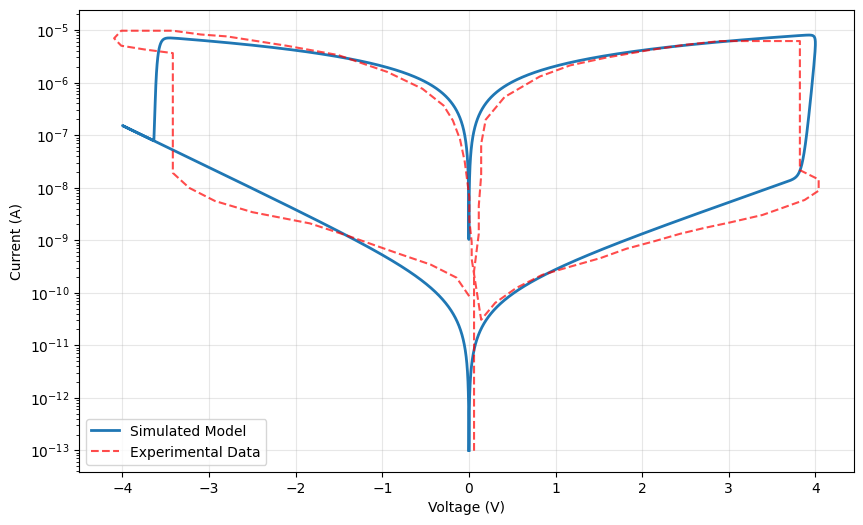

In [ ]:
#DOI: 10.1039/d0nr08725d
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physical Constants ---
k_B = 8.617e-5          # Boltzmann constant (eV/K)
T = 300                 # Temperature (K)
G0 = 0.4e-5            # DP1 conductance
L = 0.7e-9              # Device thickness (0.7nm)

# --- 2. Model Parameters ---
Ea = 2.0                # Activation Energy (eV)
beta = 0.59e-9           # Field coupling constant (eV*m/V)
k_attempt = 1e10        # Attempt frequency (Hz)

# Schottky Parameters
Is = 1.0e-10
n_set = 29
n_reset = 21
vt = 0.026

# Metallic Parameters
N_channels = 1
G_metallic = N_channels * G0

freq = 1e3                          # 1 kHz
t = np.linspace(0, 1/freq, 25000)   # 1 cycle
V_max = 4.0                         # 4.5V Amplitude
V_signal = V_max * np.sin(2 * np.pi * freq * t)
#V_signal[V_signal < 0] *= 0.4
dt = t[1] - t[0]

class MoTe2:
    def __init__(self):
        # Thresholds
        self.v_off = 0.2
        self.v_on = -0.2
        self.Eset = 3.7
        self.Ereset =3.3

        # State limits
        self.w_init = 0    # Starts in OFF State
        self.w = self.w_init
        self.p_set = 2
        self.p_reset = 0.8

    def dw_dt(self, v):
        if v > self.v_off:
            window = (1 - self.w)**self.p_set
            return k_attempt * np.exp((-(self.Eset - beta * (v/L)) / (k_B * T))) * window
        elif v < self.v_on:
            # Using -(self.w**p) to ensure a negative rate for RESET
            window = -(self.w)**self.p_reset
            return k_attempt * np.exp((-(self.Ereset - beta * (abs(v/L))) / (k_B * T))) * window
        else:
            return 0

# --- 3. Simulation Loop ---
memristor = MoTe2()
current = []
state = []
derivative = []

for v in V_signal:
    dw_val = memristor.dw_dt(v)
    derivative.append(dw_val)

    # Update and clip state variable
    memristor.w = np.clip(memristor.w + dw_val * dt, 0, 1)
    state.append(memristor.w)

    # Select ideality factor based on polarity
    if v >= 0:
        n_current = n_set
    else:
        n_current = n_reset

    # Calculate Schottky and Metallic components
    I_sch = Is * (np.exp(np.abs(v) / (n_current * vt)) - 1) * np.sign(v)
    I_met = G_metallic * v

    # Total current blending (HRS vs LRS)
    I_total = (1 - memristor.w) * I_sch + memristor.w * I_met
    I_clipped = np.maximum(np.abs(I_total), 1e-13)
    current.append(I_clipped)

# --- 4. Plotting ---

# Plot 1: State Variable vs Voltage
# plt.figure(figsize=(8, 4))
#plt.plot(V_signal, state)
#plt.title("State Variable (w) vs Voltage")
#plt.xlabel("Voltage (V)")
#plt.ylabel("State (w)")
#plt.grid(True)
#plt.show()

# Plot 2: I-V Characteristics (Log Scale)
plt.figure(figsize=(10, 6))
plt.semilogy(V_signal, current, label="Simulated Model", linewidth=2)

# Experimental Data Reference
x_exp = [0.05913,
0.05913,
0.05913,
0.05913,
0.05913,
0.05913,
0.05913,
0.05913,
0.11386,
0.11386,
0.14123,
0.14123,
0.19386,
0.4107,
0.817,
1.16857,
1.57488,
2.06118,
2.49485,
2.90116,
3.30746,
3.65903,
3.82113,
3.82113,
3.82113,
3.82113,
3.82113,
3.82113,
3.82113,
3.82113,
4.03797,
4.03797,
3.87587,
3.63166,
3.38956,
3.01063,
2.71169,
2.44012,
2.14328,
1.81908,
1.52014,
1.1412,
0.84437,
0.54543,
0.30333,
0.14123,
0.03176,
0.03176,
0.00439,
0.00439,
-0.02298,
-0.04824,
-0.10297,
-0.18508,
-0.29244,
-0.53665,
-0.94295,
-1.51136,
-2.10713,
-2.79553,
-3.09447,
-3.41867,
-3.71761,
-4.01445,
-4.09655,
-4.01445,
-3.74287,
-3.41867,
-3.41867,
-3.41867,
-3.41867,
-3.41867,
-3.41867,
-3.41867,
-3.41867,
-3.2292,
-2.93237,
-2.4987,
-1.83556,
-1.37452,
-0.82085,
-0.44191,
-0.14297,
0.01913]
y_exp = [9.83428E-14,
0.000000000000206089,
0.000000000000506541,
0.00000000000159662,
0.00000000000463213,
0.0000000000124486,
0.000000000042359,
0.000000000257535,
0.0000000013265,
0.0000000045426,
0.0000000169009,
0.000000067882,
0.000000196939,
0.000000529263,
0.00000130086,
0.00000212577,
0.00000296178,
0.00000410033,
0.00000522488,
0.0000061673,
0.0000061673,
0.0000061673,
0.0000061673,
0.0000044548,
0.0000015355,
0.00000048715,
0.000000196939,
0.0000000801258,
0.0000000351926,
0.0000000215361,
0.0000000143183,
0.00000000876208,
0.00000000582548,
0.00000000418114,
0.00000000302015,
0.00000000216767,
0.00000000170112,
0.0000000013265,
0.000000000958168,
0.00000000068771,
0.000000000457225,
0.000000000303986,
0.000000000218181,
0.000000000122892,
0.0000000000641197,
0.000000000030597,
0.000000000440058,
0.00000000091633,
0.00000000246258,
0.00000000657598,
0.0000000148769,
0.0000000311762,
0.0000000832515,
0.000000189545,
0.000000365608,
0.000000761303,
0.0000015954,
0.00000334335,
0.00000502871,
0.00000756367,
0.00000821754,
0.00000969973,
0.00000969973,
0.00000969973,
0.00000696183,
0.00000502871,
0.00000426029,
0.00000363237,
0.00000204596,
0.00000089862,
0.000000397214,
0.000000160581,
0.0000000709813,
0.0000000338713,
0.0000000190782,
0.0000000098909,
0.00000000557111,
0.00000000340924,
0.00000000208628,
0.00000000117511,
0.000000000560748,
0.000000000343149,
0.000000000193281,
0.0000000000786374]

plt.semilogy(x_exp, y_exp, 'r--', label="Experimental Data", alpha=0.7)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.legend()
plt.grid(True, which="major", ls="-", alpha=0.3)
#plt.show()
plt.savefig("WSe2.png", dpi=300)